# Ensemble validation

The 5 parameter sets calculkated in Calibration_HBV.ipynb will be used for a validation period, in which the log NSE will be calculated, a mean will be calculated and total low flow days during the navigation season.

The structure of this notebook is as follows:

### 1. Startup
### 2. Model Setup
### 3. Running model
### 4. LNSE calculation
### 5. Display results
### 6. Lowflow calculation

## 1. Startup

In [49]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [50]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [51]:
# Defining things

basin_size = 132572
q_critical = 500

In [52]:
# Choosing time period

experiment_start_date = "2019-01-01T00:00:00Z"
experiment_end_date = "2024-12-31T00:00:00Z"

validation_start = "2019-01-01T00:00:00Z"
validation_end = "2024-12-31T00:00:00Z"

In [111]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "ERA5-2019-2024"

discharge_file = Path.home() / "BEP-maxime" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [54]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [119]:
# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for calibration
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

# Align q_obs
q_obs = q_obs[(q_obs["Date"] >= validation_start_date) & (q_obs["Date"] <= validation_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

In [110]:
observed_output.head()

Date
2019-01-01    213.0
2019-01-02    213.0
2019-01-03    213.0
2019-01-04    214.0
2019-01-05    214.0
Name: Observed discharge, dtype: float64

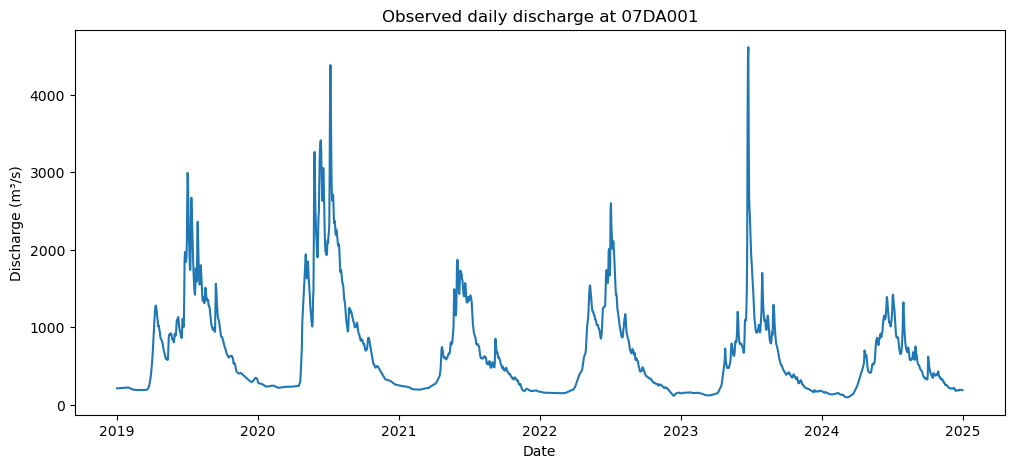

In [56]:
# Plot q_obs

plt.figure(figsize=(12, 5))
plt.plot(q_obs["Date"], q_obs["discharge_m3s"])

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Observed daily discharge at 07DA001")

plt.show()

### Generate/Load ERA5 data

In [112]:
# Generate ERA5 data
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
# )

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='2019-01-01T00:00:00Z',
    end_time='2024-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/Workyard/forcings/ERA5-2019-2024'),
    shape=PosixPath('/home/maxime/BEP-maxime/Workyard/Shapefiles/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_ERA5_2019_2024_evspsblpot.nc',
        'pr': 'combined_ERA5_2019_2024_pr.nc',
        'rsds': 'combined_ERA5_2019_2024_rsds.nc',
        'tas': 'combined_ERA5_2019_2024_tas.nc'
    }
)

### Load parameter sets & initial storages

In [75]:
# Load calibration constants

# par_0 = [4.45787, 0.42307, 201.57602, 2.36497, 0.26755, 8.62964, 0.083568, 0.0037073, 0.29645]
# par_0 = [2.79874, 0.49211, 255.96478, 1.782968, 0.503199, 6.095956, 0.33279, 0.10539, 0.63857]
# par_0 = [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606]         # 0.725 val, 0.x cal - Fav run 2
# par_0 = [6.28908, 0.423917, 173.56627, 1.63144, 0.402586, 6.56151, 0.0456809, 0.00313744, 0.516696]                 # 0.702 val, 0.x cal
# par_0 = [6.4919, 0.386877, 221.78625, 1.388269, 0.276453, 4.9870704, 0.04126777, 0.05640195, 1.148877]              # 0.668 val, 0.x cal
# par_0 = [7.502398, 0.38028, 194.1899, 1.680197, 0.47956, 4.8566806, 0.041745354, 0.02833896, 1.051862]              # 0.677 val, 0.x cal
# par_0 = [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392]                        # 0.781 val, 0.776 cal
# par_0 = [6.16512, 0.4369419, 151.2515900, 1.727835, 0.3771705, 6.19265974, 0.06959136, 0.001310818, 0.8130732]      # 0.664 val, 0.791 cal
# par_0 = [5.7107, 0.441634, 172.81305, 1.87367, 0.588802, 5.498147, 0.060305, 0.019666, 1.2011814]                    # x val, 0.73 cal         Start of 5+ months exclusion
# par_0 = [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504]                    # 0.82 val, 0.818 cal - Fav run 1      
# par_0 = [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]                    #  val,  0.77 cal    
# par_0 = [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857]                           # 0.78 val, 0.71 cal - potential inclusion

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]
]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"          # Snowmelt factor
               ]

# Initial: par_0 = [5.085, 0.55, 100.373, 1.612, 0.545, 3.801, 0.196, 0.00, 0.185]

5

In [59]:
# Storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

## 2. Model setup

In [113]:
def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config
    )

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge"
    )

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

## 3. Running model

In [114]:
def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing
        )

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Filter observed data by day
    observed_daily = observed_output
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)
    ensemble_data['Observed discharge'] = observed_daily

    return ensemble_data

In [115]:
ensemble_data = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=ERA5_forcing
)

ensemble_data.head()

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

,Set 1,Set 2,Set 3,Set 4,Set 5,Mean,Observed discharge
2019-01-02,0.0,0.0,0.0,0.0,0.0,0.0,213.0
2019-01-03,0.0,0.0,0.0,0.0,0.0,0.0,213.0
2019-01-04,0.0,0.0,0.0,0.0,0.0,0.0,214.0
2019-01-05,0.0,0.0,0.0,0.0,0.0,0.0,214.0
2019-01-06,0.0,0.0,0.0,0.0,0.0,0.0,214.0


## 4. LNSE Calculation

In [124]:
# Calculate log NSE

def LNSE(sim, obs):
    
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    # Avoid log(0)
    eps = 0.00000000001

    log_sim = np.log(sim + eps)
    log_obs = np.log(obs + eps)

    return 1 - np.sum((log_obs - log_sim) ** 2) / np.sum((log_obs - np.mean(log_obs)) ** 2)

In [151]:
# Call log NSE for relevant timeperiod

def lnse_ensemble(ensemble_data, lnse_start, lnse_end):

    # Select evaluation period - skip first year for storages to fill
    combined_data = ensemble_data[
        (ensemble_data.index >= lnse_start) &
        (ensemble_data.index <= lnse_end)
    ].dropna()

    # Exclude winter months
    combined_data = combined_data[
        ~combined_data.index.month.isin([12, 1, 2, 3, 4])
    ]

    lnse_results = []

    # Calculate LNSE for all sets
    for i in range(len(par_ensemble)):
        lnse_value = LNSE(
            combined_data[f"Set {i+1}"],
            combined_data["Observed discharge"]
        )

        # Append LNSE
        lnse_results.append({
            "Set": f"Set {i+1}",
            "LNSE": lnse_value
        })

    # Calculate LNSE of ensemble mean
    mean_lnse = LNSE(
        combined_data["Mean"],
        combined_data["Observed discharge"]
    )

    # Append LNSE
    lnse_results.append({
        "Set": "Ensemble mean",
        "LNSE": mean_lnse
    })

    lnse_results = pd.DataFrame(lnse_results)

    return lnse_results

In [152]:
lnse_results = lnse_ensemble(
    ensemble_data=ensemble_data,
    lnse_start=evaluation_start,
    lnse_end=validation_end_date
)

lnse_results

,Set,LNSE
0,Set 1,0.728192
1,Set 2,0.771258
2,Set 3,0.777863
3,Set 4,0.727285
4,Set 5,0.744617
5,Ensemble mean,0.812287


## 5. Display results

In [171]:
def plot_ensemble(ensemble_data, plot_start, plot_end, q_critical):

    plot_start = pd.to_datetime(plot_start)
    plot_end = pd.to_datetime(plot_end)

    # Filter data to start & end time
    plot_data = ensemble_data[
        (ensemble_data.index >= plot_start) &
        (ensemble_data.index <= plot_end)
    ].dropna()

    # Define figure
    plt.figure()
    plt.figure(figsize=(20, 8))

    # Plot sets, observed data, ensemble mean and axhline, respectively
    for i in range(len(par_ensemble)):
        plt.plot(plot_data.index, plot_data[f"Set {i+1}"], color="orange", alpha=0.3, label="Parameter sets" if i == 0 else None)

    plt.plot(plot_data.index, plot_data["Observed discharge"], label="Observed discharge", linewidth=3)
    plt.plot(plot_data.index, plot_data["Mean"], label="Ensemble mean", linewidth=3)
    plt.axhline(y=q_critical, linestyle=":", color="black", label=f"Critical discharge ({q_critical} m³/s)")

    # Extras
    plt.xlabel("Date")
    plt.ylabel("Discharge (m³/s)")
    plt.title("Observed vs modelled ensemble discharge at 07DA001")
    plt.legend()
    plt.grid(True)

    plt.show()

<Figure size 640x480 with 0 Axes>

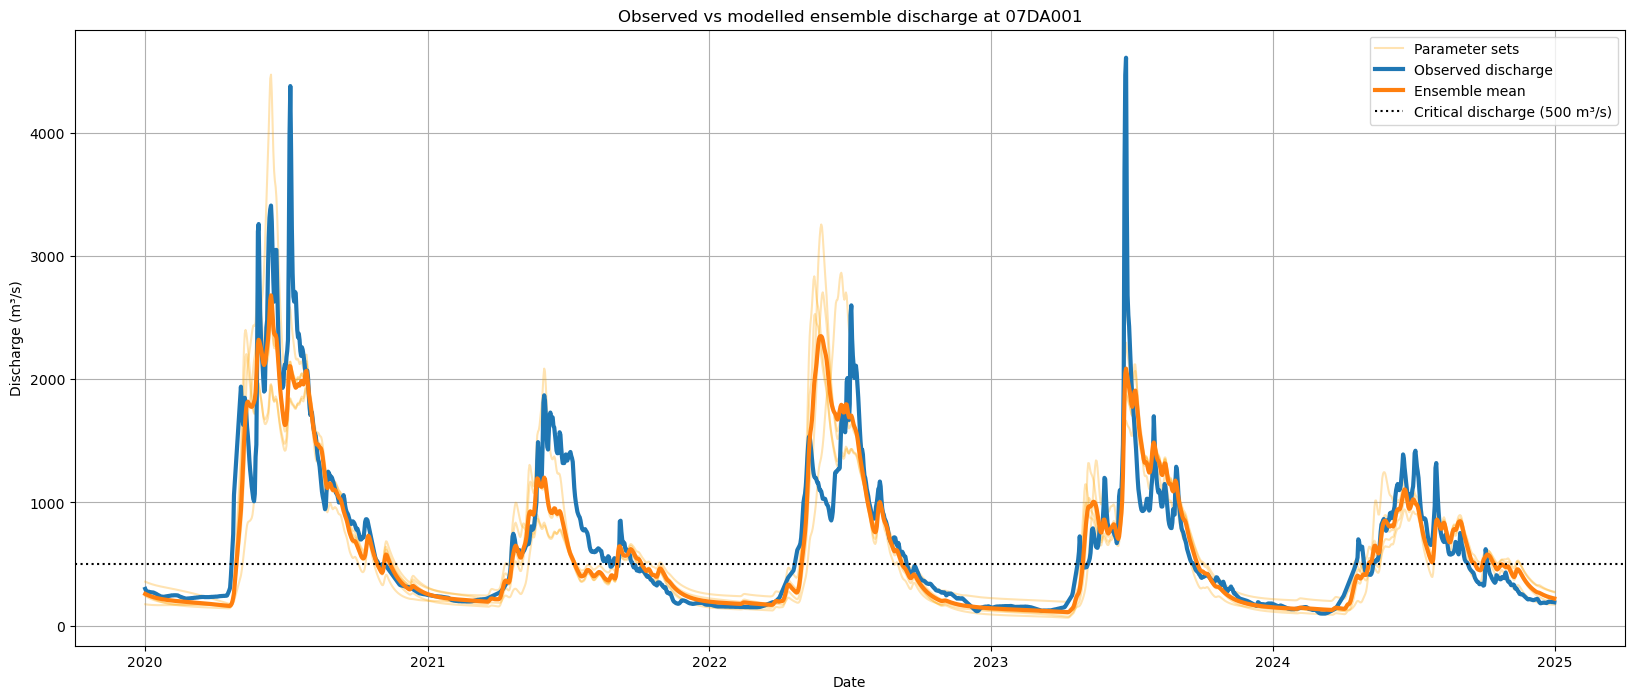

In [172]:
# Plot for full evaluation period

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=evaluation_start,
    plot_end=validation_end_date,
    q_critical=q_critical
)

<Figure size 640x480 with 0 Axes>

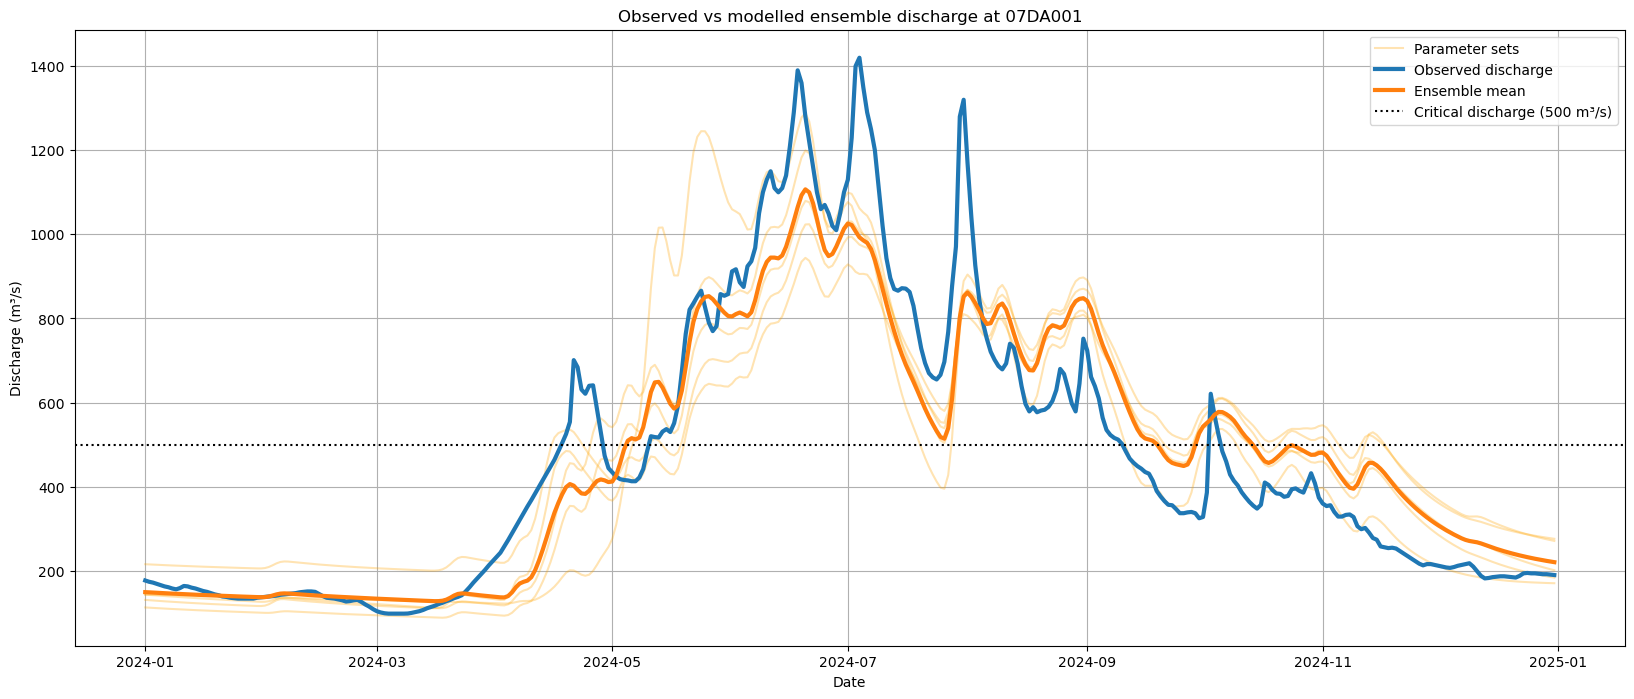

In [177]:
# Plot for selected year

selected_year = 2024

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31"),
    q_critical=q_critical
)

## 6. Lowflow calculation

In [69]:
def days_counter_ensemble(plot_data, start_date, end_date, q_critical):

    start_date = pd.to_datetime(start_date).tz_localize(None).normalize()
    end_date = pd.to_datetime(end_date).tz_localize(None).normalize()

    years = list(range(start_date.year, end_date.year + 1))

    lowflow_days = []

    for i in range(len(years)):

        year = years[i]

        # Define start and end month-day
        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")

        year_data = plot_data[
            (plot_data.index >= year_start) &
            (plot_data.index <= year_end)
        ]

        observed_lowflow_days = 0
        modelled_lowflow_days = []

        # Loop through Run 1 to Run 5
        for k in range(1, len(par_ensemble) + 1):

            run_lowflow_days = 0

            for j in range(len(year_data)):

                modelled_q = year_data.iloc[j][f"Run {k}"]

                if modelled_q < q_critical:
                    run_lowflow_days += 1

            modelled_lowflow_days.append(run_lowflow_days)

        # Count observed low-flow days
        for j in range(len(year_data)):

            observed_q = year_data.iloc[j]["Observed discharge"]

            if observed_q < q_critical:
                observed_lowflow_days += 1

        average_modelled_lowflow_days = np.mean(modelled_lowflow_days)

        lowflow_days.append({
            "year": year,
            "observed_lowflow_days": observed_lowflow_days,
            "run_1_lowflow_days": modelled_lowflow_days[0],
            "run_2_lowflow_days": modelled_lowflow_days[1],
            "run_3_lowflow_days": modelled_lowflow_days[2],
            "run_4_lowflow_days": modelled_lowflow_days[3],
            "run_5_lowflow_days": modelled_lowflow_days[4],
            "average_modelled_lowflow_days": np.round(average_modelled_lowflow_days)
        })

    lowflow_days = pd.DataFrame(lowflow_days)

    return lowflow_days

In [70]:
lowflow_days = days_counter_ensemble(
    plot_data=plot_data,
    start_date=evaluation_start,
    end_date=validation_end_date,
    q_critical=q_critical
)

lowflow_days

,year,observed_lowflow_days,run_1_lowflow_days,run_2_lowflow_days,run_3_lowflow_days,run_4_lowflow_days,run_5_lowflow_days,average_modelled_lowflow_days
0,2020,0,0,0,0,0,0,0.0
1,2021,0,0,0,0,0,0,0.0
2,2022,0,0,0,0,0,0,0.0
3,2023,0,0,0,0,0,0,0.0
4,2024,0,0,0,0,0,0,0.0
